# Статистика, DS-поток
## Марафон-домашка SM.3, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Баллы за задание:**

* Задача 1 &mdash; 60 баллов
* Задача 2 &mdash; 80 баллов
* Задача 3 &mdash; 60 баллов

**Важность задач:**

* *высокая:* задачи 1, 2;
* *средне-высокая:* задача 3.

Степень важности задач не связана с количеством баллов и определяется только на основе оценки полезности задачи с точки зрения усвоения текущего и дальнейшего материала. Например, если вы что-то не успеваете, рекомендуется в первую очередь выполнять более важные задачи.

In [118]:
# Bot check

# HW_ID: ds_sm3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [111]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.5, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])
RANDOM_STATE = 42
from tqdm.notebook import tqdm
from ucimlrepo import fetch_ucirepo 
import pandas as pd
from typing import Tuple

*Замечания.*
1. Вы должны помнить о разнице между оценкой / доверительным интервалом и *реализацией* оценки / доверительного интервала. На практике обычно слово *реализация* опускается.
2. Если оценка/интервал получен на лекции/семинаре, то нужно просто выписать формулу. Если такой случай не рассматривался, то нужно добавить его вывод.
3. Выборку надо сгенерировать один раз. Дело в том, что на практике при недостаточном размере выборки разумнее дособрать выборку, чем заново проводить все измерения.

______________
### Задача 1.

Пусть $X = (X_1, ..., X_n)$ &mdash; выборка из распределения $U[0, \theta]$. Постройте асимптотические доверительные интервалы: Вальда и на основе аппроксимации $X_{(n)}$ некоторым распределением (см. задание SM.3, теор. часть). Для этого сгенерируйте выборку $X_1, ... X_{N}, N = 100$ и постройте график доверительных интервалов уровня доверия $0.95$, вычисленных для всех подвыборок размера $n$ вида $X_1, ... X_n$, $1 \le n \le 100$, используя функцию из задания SM.2, практической части. Нужно нанести на график точки выборки.

Для двух статистик, используемых при построении интервалов, запишите аппроксимацию некоторым распределением неформально в виде "статистика по выборке достаточно большого размера приближенно имеет такое-то распределение". 

Сделайте вывод о том, как влияет на ширину интервала вид статистики и аппроксимация.

**Решение:**

In [14]:
def draw_confidence_interval(
    left, right, estimation=None, sample=None, 
    ylim=(None, None), color_estimation=['#e7298a'], color_interval=['#7570b3'], 
    color_sample='#66a61e', label_estimation=['Оценка']
):
    '''
    Рисует доверительный интервал и оценку в зависимости от размера выборки.
    
    :param left: левые границы интервалов (в зависимости от n)
    :param right: правые границы интервалов (в зависимости от n)
    :param estimation: оценки (в зависимости от n)
    :param sample: выборка
    :param ylim: ограничение вертикальной оси
    :param color_estimation: цвет оценки
    :param color_interval: цвет интервала
    :param color_sample: цвет выборки
    :param label_estimation: подпись для оценки
    '''

    n_range = np.arange(left[0].size) + 1


    if sample is not None:
        plt.figure(figsize=(15, 7))
        plt.scatter(n_range, sample, color=color_sample, s=8, alpha=0.6, edgecolors='black')
        plt.title('Точки выборки $X$')
        plt.show()

    plt.figure(figsize=(15, 7))
    if estimation is not None:
        i = 0
        while i < len(estimation):
            estimation_i = estimation[i]
            color_estimation_i = color_estimation[i]
            label_estimation_i = label_estimation[i]
            plt.plot(n_range[1:], estimation_i[1:], color=color_estimation_i, lw=2, label=label_estimation_i)
            # plt.scatter(n_range[1:], estimation_i[1:], color=color_estimation_i, s=10)
            i += 1

    i = 0
    while i < len(left):
        left_i = left[i]
        right_i = right[i]
        color_interval_i = color_interval[i]
        plt.plot(n_range[1:], left_i[1:], color=color_interval_i, lw=3, label=f'Нижняя и верхняя граница {i + 1}-й оценки')
        plt.plot(n_range[1:], right_i[1:], color=color_interval_i, lw=3)
        plt.fill_between(n_range[1:], left_i[1:], right_i[1:], color=color_interval_i, alpha=0.15)
        i += 1
    if ylim != (None, None):
        plt.ylim(ylim)
    plt.xlabel("Размер выборки")
    plt.legend()
    plt.show()

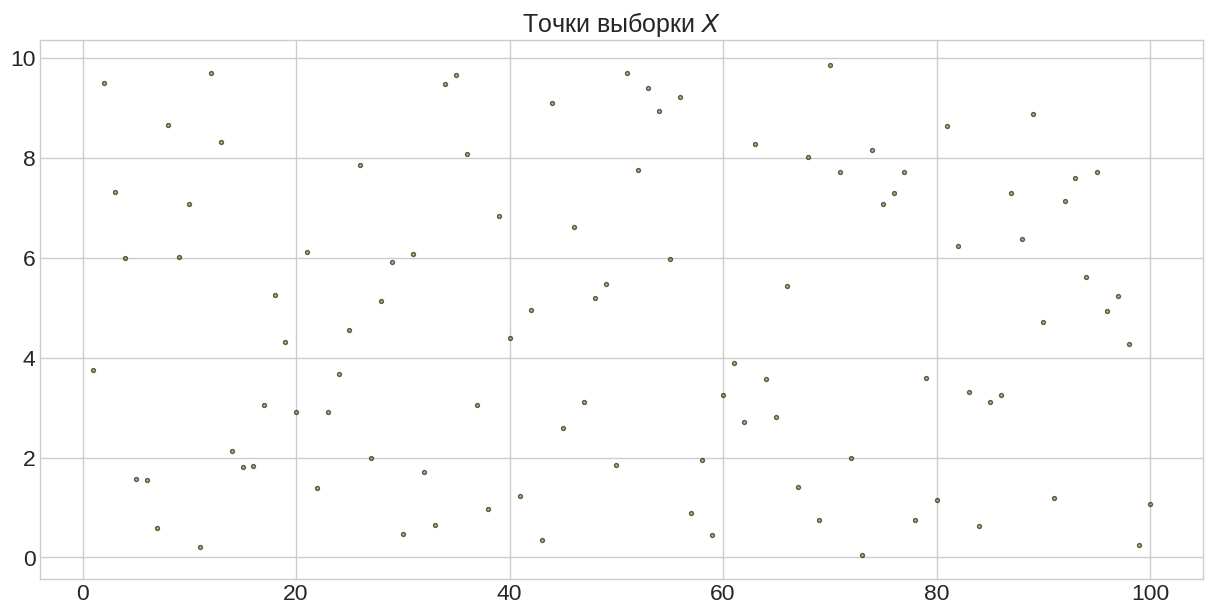

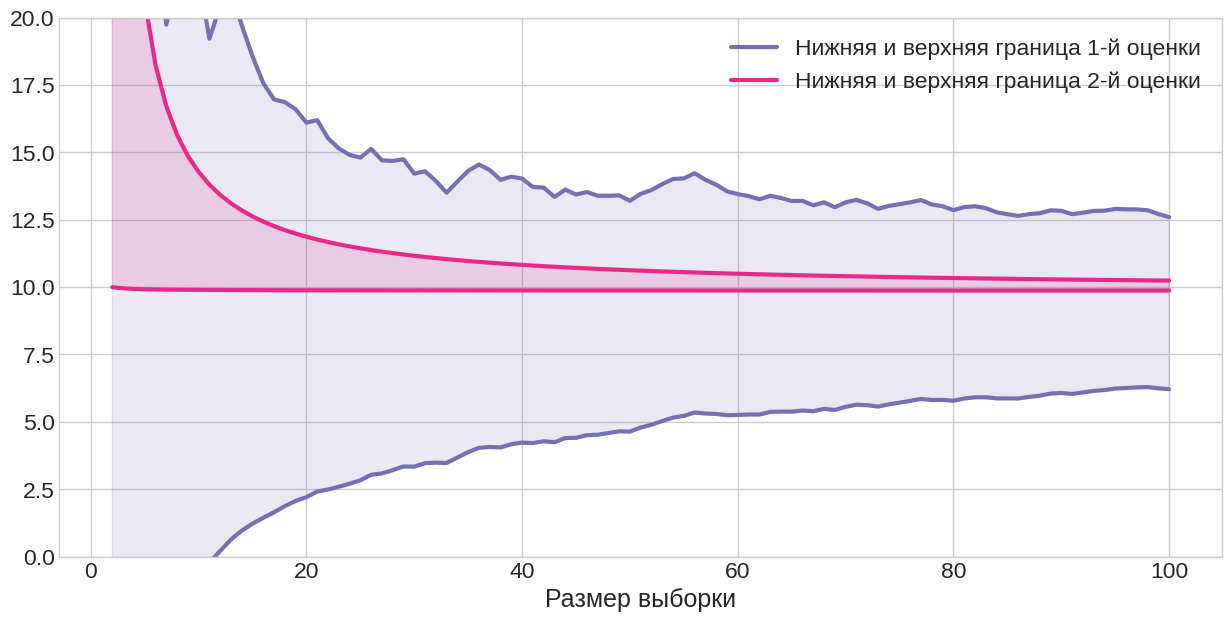

In [102]:
size = 100
n_range = np.arange(size) + 1

thetta = 10
sample = sps.uniform.rvs(size=size, loc=0, scale=thetta, random_state=RANDOM_STATE)

alpha = 0.95
z = sps.norm.ppf((1 + alpha) / 2)

estimation = 2 * sample.cumsum() / n_range
left_w = estimation - z * estimation * np.sqrt(3 / n_range)
right_w = estimation + z * estimation * np.sqrt(3 / n_range)

left_g = np.max(sample) / np.power((1 + alpha) / 2, 1 / n_range)
right_g = np.max(sample) / np.power((1 - alpha) / 2, 1 / n_range)

plt.style.use('seaborn-v0_8-whitegrid')
draw_confidence_interval(
    left=[left_w, left_g], 
    right=[right_w, right_g], 
    sample=sample, 
    color_interval=['#7570b3','#e7298a'],
    ylim=[0, 20]
)


Сравните два исследуемых интервала по величине доли покрытия истинного значения $\theta$. Посмотрите примеры в ноутбуке с семинара.

**Вывод:** <...>

__________________
### Задача 2.
 В данном задании вам нужно изучить доверительные интервалы для параметра сдвига в нормальной модели в случае неизвестной дисперсии. Требуется построить: 
 * асимтотический доверительный интервал при помощи центральной предельной теоремы и леммы Слуцкого;
 * точный неасимптотический при помощи распределений хи-квадрат, Стьюдента.

Вывод этих интервалов был разобран на лекции. Выпишите только ответы.

Асимптотический доверительный интервал:

$$
\bar X \pm z_{\frac{1+\alpha}{2}}\cdot\dfrac{s}{\sqrt{n}},
$$


Точный доверительный интервал: 

$$
\bar X \pm t_{n-1,\,\frac{1+\alpha}{2}}\cdot\dfrac{s}{\sqrt{n - 1}}.
$$

Реализуйте функции построения этих интервалов по выборке. Задокументируйте функции (см. [гайд](https://realpython.com/documenting-python-code/)).

In [117]:
def calculate_asymptotic_confidence_intervals(
    sample: np.ndarray, alpha: float = 0.95
) -> Tuple[np.float64, np.float64]:
    """Вычисляет реализации статистик границ асимптотического доверительного интервала
    для параметра сдвига в нормальной модели в случае неизвестной дисперсии.

    Args:
        sample (np.ndarray): выборка
        alpha (float): уровень доверия
            (default is 0.95)
    
    Returns:
        left, right (Tuple[np.float64, np.float64]): левая и правая граница интервала
    """

    n = len(sample)
    x_bar = np.mean(sample)
    z = sps.norm.ppf((1 + alpha) / 2)
    s = np.std(sample)
    left = x_bar - z * s / np.sqrt(n)
    right = x_bar + z * s / np.sqrt(n)
    return (left, right)

def calculate_confidence_intervals(
    sample: np.ndarray, alpha: float = 0.95
) -> Tuple[np.float64, np.float64]:
    """Вычисляет реализации статистик границ точного доверительного интервала
    для параметра сдвига в нормальной модели в случае неизвестной дисперсии.

    Args:
        sample (np.ndarray): выборка
        alpha (float): уровень доверия
            (default is 0.95)
    
    Returns:
        left, right (Tuple[np.float64, np.float64]): левая и правая граница интервала
    """

    n = len(sample)
    x_bar = np.mean(sample)
    t = sps.t.ppf((1 + alpha) / 2, n - 1)
    s = np.std(sample)
    left = x_bar - t * s / np.sqrt(n - 1)
    right = x_bar + t * s / np.sqrt(n - 1)    
    return (left, right)

Сгенерируйте выборку из нормального распределения и сравните два доверительных интервала в зависимости от размера выборки. Для сравнения отобразите оба интервала на одном графике. Проследите за тем, чтобы было видно, как соотносятся размеры интервалов. Поясните теоретическую причину такого поведения доверительных интервалов.

*Указание*: рассматривайте длину выборки около 20-30.

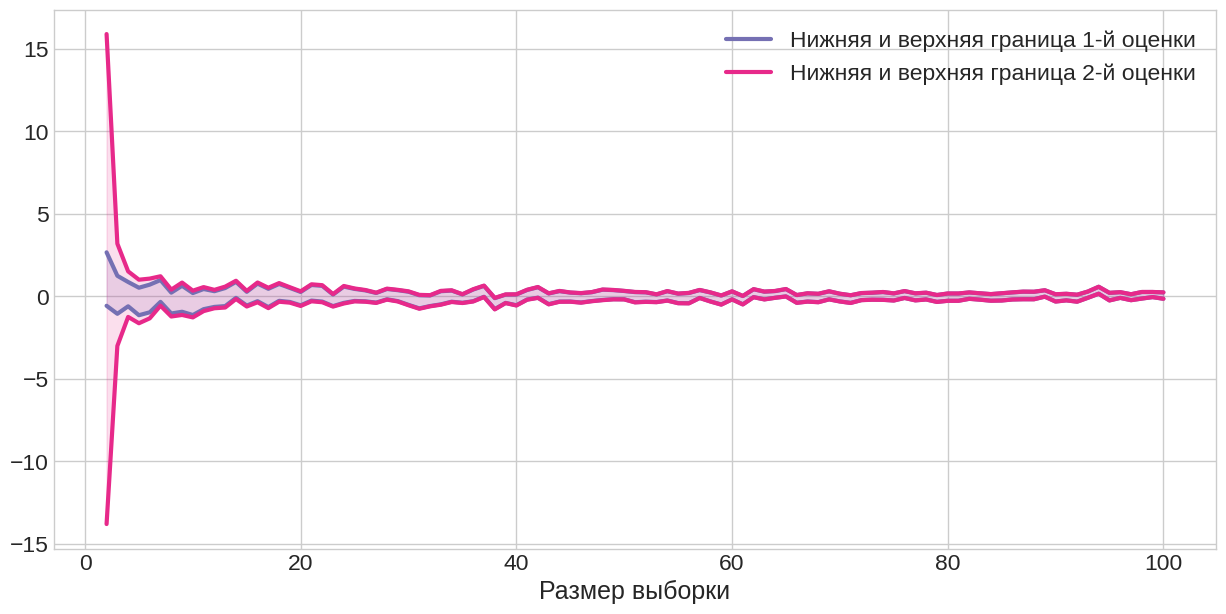

In [116]:
loc = 0
scale = 1
size = 100
n_range = np.arange(size) + 1
left_a = np.zeros(size)
right_a = np.zeros(size)
left_p = np.zeros(size)
right_p = np.zeros(size)

for n in n_range:
    sample = sps.norm.rvs(size=n, loc=loc, scale=1)
    left_a_n, right_a_n = calculate_asymptotic_confidence_intervals(sample)
    left_p_n, right_p_n = calculate_confidence_intervals(sample)
    left_a[n - 1] = left_a_n
    right_a[n - 1] = right_a_n
    left_p[n - 1] = left_p_n
    right_p[n - 1] = right_p_n

plt.style.use('seaborn-v0_8-whitegrid')
draw_confidence_interval(
    left=[left_a, left_p], 
    right=[right_a, right_p], 
    color_interval=['#7570b3','#e7298a']
)

Сравните также эти интервалы по величине доли покрытия истинного значения параметра сдвига.

In [41]:
print('Доля покрытия истинного значения параметра сдвига асимптотическим интервалом:', ((left_a <= loc) & (right_a >= loc)).sum()/size)
print('Доля покрытия истинного значения параметра сдвига точным интервалом:', ((left_p <= loc) & (right_p >= loc)).sum()/size)

Доля покрытия истинного значения параметра сдвига асимптотическим интервалом: 0.91
Доля покрытия истинного значения параметра сдвига точным интервалом: 0.95


Попросим гпт провести множественное тестирование

  0%|          | 0/1000 [00:00<?, ?it/s]

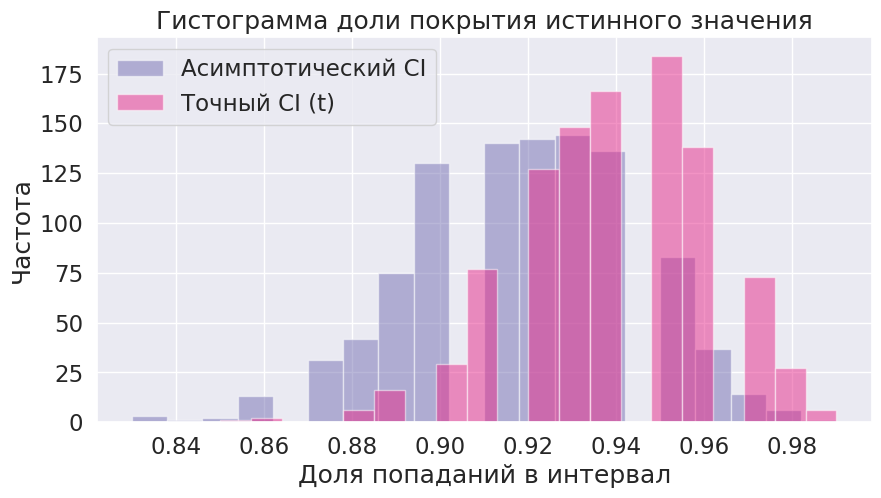

In [45]:
loc = 0
scale = 1
size = 100      
n_sim = 1000    

coverage_asym = np.zeros(n_sim)
coverage_exact = np.zeros(n_sim)

for sim in tqdm(range(n_sim)):
    left_a = np.zeros(size)
    right_a = np.zeros(size)
    left_p = np.zeros(size)
    right_p = np.zeros(size)
    
    for n in range(1, size+1):
        sample = sps.norm.rvs(size=n, loc=loc, scale=scale)
        left_a[n-1], right_a[n-1] = calculate_asymptotic_confidence_intervals(sample)
        left_p[n-1], right_p[n-1] = calculate_confidence_intervals(sample)
    
    coverage_asym[sim] = np.mean((left_a <= loc) & (right_a >= loc))
    coverage_exact[sim] = np.mean((left_p <= loc) & (right_p >= loc))

plt.figure(figsize=(10,5))
plt.hist(coverage_asym, bins=20, alpha=0.5, label='Асимптотический CI')
plt.hist(coverage_exact, bins=20, alpha=0.5, label='Точный CI (t)')
plt.xlabel('Доля попаданий в интервал')
plt.ylabel('Частота')
plt.title('Гистограмма доли покрытия истинного значения')
plt.legend()
plt.show()

In [48]:
mean_coverage_asym = np.mean(coverage_asym)
mean_coverage_exact = np.mean(coverage_exact)

print(f'Средняя доля покрытия истинного значения асимптотическим CI: {mean_coverage_asym:.4f}')
print(f'Средняя доля покрытия истинного значения точным CI: {mean_coverage_exact:.4f}')

Средняя доля покрытия истинного значения асимптотическим CI: 0.9185
Средняя доля покрытия истинного значения точным CI: 0.9393


**Вывод:** Видим, что реальный уровень доверия в обоих случаях слегка заниженный, но для асимптотического интервала он ниже, чем для точного.
Это связано, прежде всего, с малыми размерами выборки, где эффект расхождения с нормальной аппроксимацией проявляется наиболее ярко.

Cкачайте данные <a href="http://archive.ics.uci.edu/ml/datasets/wine">`wine dataset`</a> и рассмотрите столбцы `Alcalinity of ash`, `Nonflavanoid phenols`, `Proanthocyanins` и `Hue` для вина *первого типа*. Тип вина указан в первом столбце.

Постройте доверительные интервалы для параметров сдвига каждого из столбцов, предполагая, что столбцы имеют нормальное распределение. Нужно построить доверительные интервалы обоих рассмотренных выше типов. Запишите их в виде таблицы.

In [73]:
X = pd.read_csv("wine.data", header=None)

X.columns = [
    "Class",
    "Alcohol",
    "Malic acid",
    "Ash",
    "Alcalinity of ash",
    "Magnesium",
    "Total phenols",
    "Flavanoids",
    "Nonflavanoid phenols",
    "Proanthocyanins",
    "Color intensity",
    "Hue",
    "OD280/OD315 of diluted wines",
    "Proline"
]

X.head(3)

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185


In [77]:
mask = (X.loc[:, 'Class'] == 1)
sel_cols = ['Alcalinity of ash', 'Nonflavanoid phenols', 'Proanthocyanins', 'Hue']

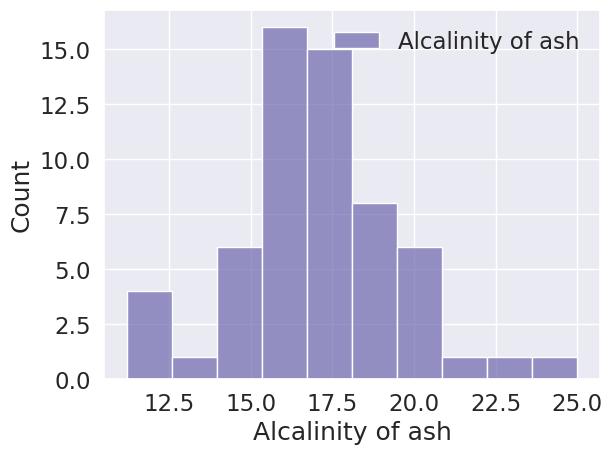

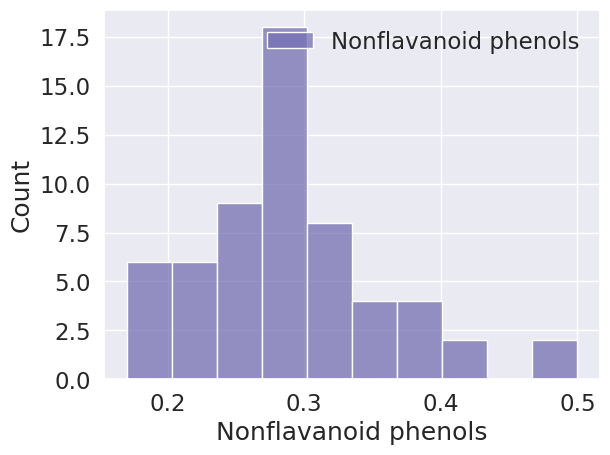

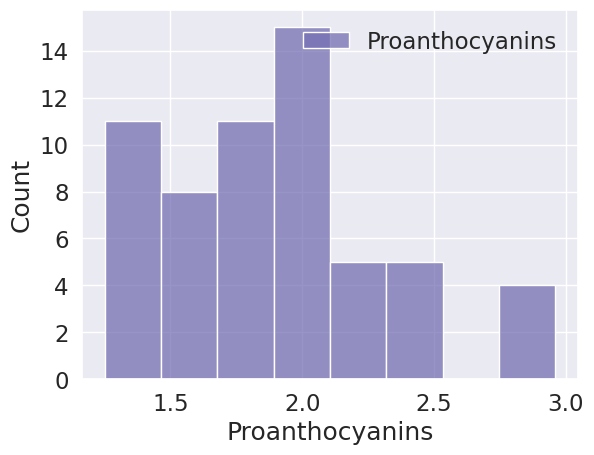

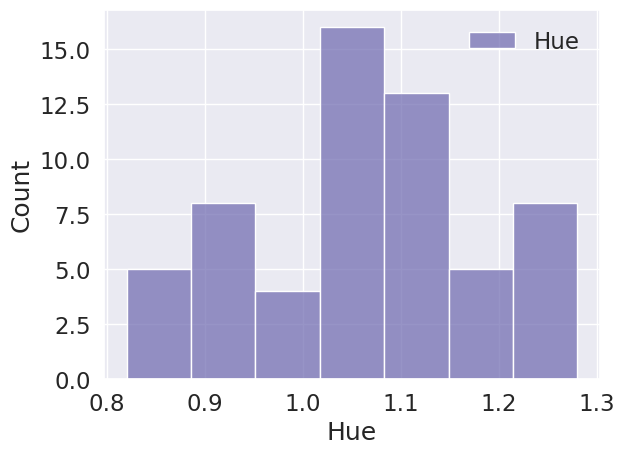

In [82]:
for col in sel_cols:
    sns.histplot(X.loc[mask, col], label=col)
    plt.legend()
    plt.show()

In [88]:
ncols = len(sel_cols)
lefts_a = np.zeros(ncols)
rights_a = np.zeros(ncols)
lefts_p = np.zeros(ncols)
rights_p = np.zeros(ncols)

for i, col in enumerate(sel_cols):
    left_a_n, right_a_n = calculate_asymptotic_confidence_intervals(X.loc[mask, col])
    left_p_n, right_p_n = calculate_confidence_intervals(X.loc[mask, col])
    lefts_a[i] = left_a_n
    rights_a[i] = right_a_n
    lefts_p[i] = left_p_n
    rights_p[i] = right_p_n
    
pd.DataFrame({'Точная левая граница': lefts_p, 'Точная правая граница': rights_p, 
              'Асимптотическая левая граница': lefts_a, 'Асимптотическая правая граница': rights_a}, index=sel_cols)

,Точная левая граница,Точная правая граница,Асимптотическая левая граница,Асимптотическая правая граница
Alcalinity of ash,16.373713,17.700863,16.393084,17.681492
Nonflavanoid phenols,0.271745,0.308255,0.272278,0.307722
Proanthocyanins,1.791926,2.006718,1.795061,2.003583
Hue,1.031678,1.092389,1.032564,1.091503


In [90]:
print('Количество элементов первого класса:', mask.sum())

Количество элементов первого класса: 59


**Вывод:** Интервалы для математического ожидания действительно отличаются несущественно. Однако точный доверительный интервал даёт немного более широкую оценку по сравнению с асимптотическим. Это ожидаемо, так как размер выборки относительно небольшой, и поправка на $t$-распределение делает интервал более консервативным.

__________________
### Задача 3. 

Пусть $X_1, ..., X_n$ — выборка из распределения $\mathcal{N}(a, \sigma^2)$. Постройте точную доверительную область для параметра $\theta = (a, \sigma^2)$ уровня доверия $\alpha=0.95$ для сгенерированной выборки размера $n \in \{5, 20, 50\}$ из стандартного нормального распределения. Подумайте, как лучше разместить графики, чтобы читателю было удобнее воспринимать результаты.

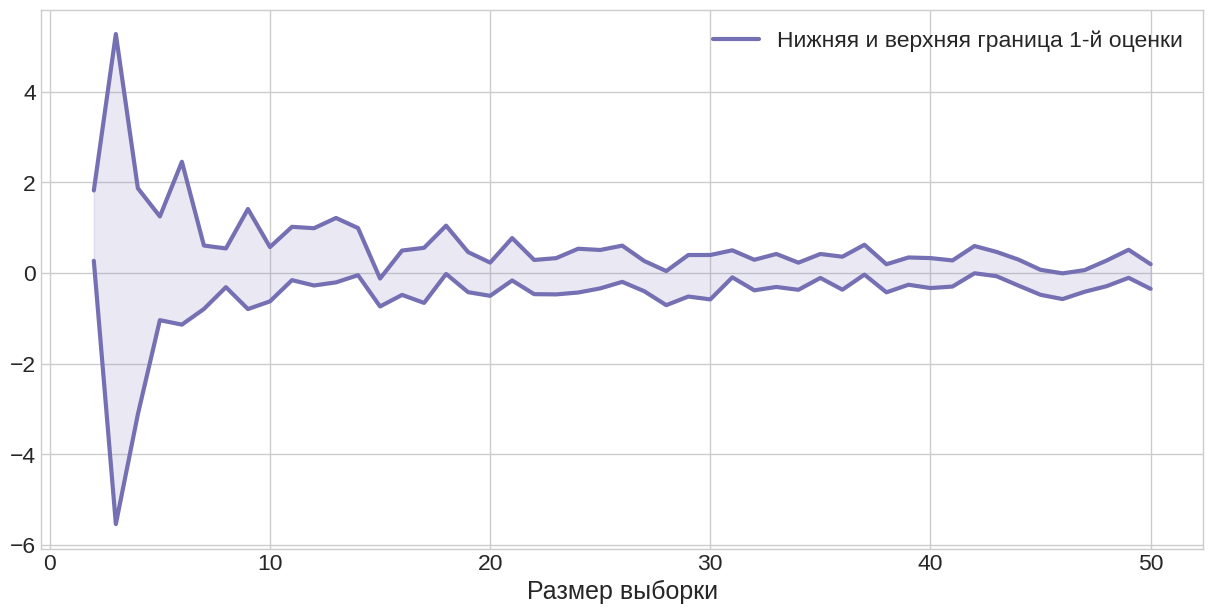

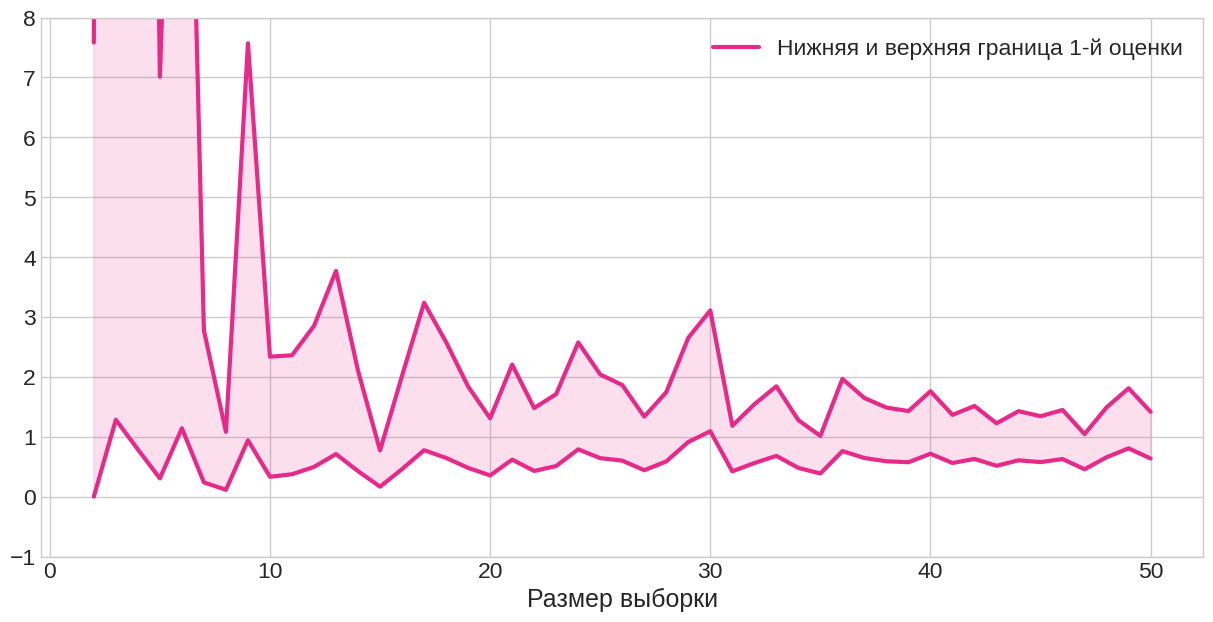

In [101]:
max_size = 50
n_range = np.arange(max_size) + 1
loc, scale = 0, 1
alpha = 0.95
left_a = np.zeros(len(n_range))
right_a = np.zeros(len(n_range))
left_s = np.zeros(len(n_range))
right_s = np.zeros(len(n_range))

for i, n in enumerate(n_range):
    sample = sps.norm.rvs(loc=loc, scale=scale, size=n)
    left_a_n, right_a_n = calculate_confidence_intervals(sample)
    left_a[i] = left_a_n
    right_a[i] = right_a_n

    left_s[i] = n * np.var(sample) / sps.chi2.ppf((1 + alpha) / 2, n - 1)
    right_s[i] = n * np.var(sample) / sps.chi2.ppf((1 - alpha) / 2, n - 1)

plt.style.use('seaborn-v0_8-whitegrid')
draw_confidence_interval(
    left=[left_a], 
    right=[right_a], 
    color_interval=['#7570b3']
)
draw_confidence_interval(
    left=[left_s], 
    right=[right_s], 
    color_interval=['#e7298a'],
    ylim=[-1, 8],
)

Исследуйте построенную доверительную область по величине доли покрытия параметра $\theta$.

In [106]:
print('Доля покрытия истинного значения параметра сдвига точным интервалом:', ((left_a <= loc) & (right_a >= loc)).sum()/max_size)
print('Доля покрытия истинного значения параметра дисперсии точным интервалом:', ((left_s <= scale**2) & (right_s >= scale**2)).sum()/max_size)

Доля покрытия истинного значения параметра сдвига точным интервалом: 0.92
Доля покрытия истинного значения параметра дисперсии точным интервалом: 0.9


Попросим гпт провести множественное тестирование

  0%|          | 0/1000 [00:00<?, ?it/s]

Среднее покрытия (сдвиг, t-интервал): 0.9307000000000001
Std покрытия (сдвиг, t-интервал): 0.03055994109941966
Среднее покрытия (дисперсия, chi²-интервал): 0.93086
Std покрытия (дисперсия, chi²-интервал): 0.029503565886177197


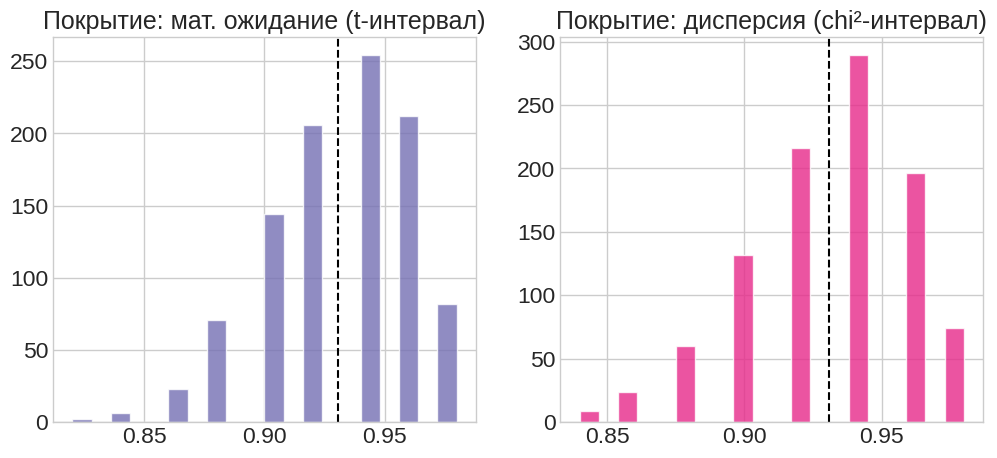

In [109]:
def one_run(max_size=50, loc=0, scale=1, alpha=0.95):
    n_range = np.arange(max_size) + 1
    left_a = np.zeros(len(n_range))
    right_a = np.zeros(len(n_range))
    left_s = np.zeros(len(n_range))
    right_s = np.zeros(len(n_range))

    for i, n in enumerate(n_range):
        sample = sps.norm.rvs(loc=loc, scale=scale, size=n)

        # доверительный интервал для среднего
        left_a_n, right_a_n = calculate_confidence_intervals(sample)
        left_a[i], right_a[i] = left_a_n, right_a_n

        # доверительный интервал для дисперсии
        S2 = np.var(sample)
        chi_low = sps.chi2.ppf((1 - alpha) / 2, df=n - 1)
        chi_high = sps.chi2.ppf((1 + alpha) / 2, df=n - 1)
        left_s[i] = n * S2 / chi_high
        right_s[i] = n * S2 / chi_low

    coverage_a = ((left_a <= loc) & (right_a >= loc)).sum() / max_size
    coverage_s = ((left_s <= scale**2) & (right_s >= scale**2)).sum() / max_size
    return coverage_a, coverage_s


# количество симуляций
n_sim = 1000
results_a = np.zeros(n_sim)
results_s = np.zeros(n_sim)

for i in tqdm(range(n_sim)):
    ca, cs = one_run()
    results_a[i] = ca
    results_s[i] = cs

# вывод статистик
print("Среднее покрытия (сдвиг, t-интервал):", results_a.mean())
print("Std покрытия (сдвиг, t-интервал):", results_a.std())
print("Среднее покрытия (дисперсия, chi²-интервал):", results_s.mean())
print("Std покрытия (дисперсия, chi²-интервал):", results_s.std())

# гистограммы
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(results_a, bins=20, color="#7570b3", alpha=0.8)
plt.axvline(results_a.mean(), color="black", linestyle="--")
plt.title("Покрытие: мат. ожидание (t-интервал)")

plt.subplot(1,2,2)
plt.hist(results_s, bins=20, color="#e7298a", alpha=0.8)
plt.axvline(results_s.mean(), color="black", linestyle="--")
plt.title("Покрытие: дисперсия (chi²-интервал)")

plt.show()


**Вывод:** В целом результат аналогичен предыдущим экспериментам: фактический уровень доверия немного ниже заявленного уровня точного доверительного интервала. Однако расхождения находятся в пределах статистической погрешности, что подтверждается как средними значениями, так и разбросом (стандартным отклонением) оценок покрытия при многократных симуляциях.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока